**EDA**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("output/Lulu_Mall_Sales_Cleaned.csv")

## Analysis 1: Revenue by Product Category

### Business Question

Which product categories generate the highest revenue?

### Objective

To compare revenue generated by different product categories and identify the major revenue-driving categories.

### Approach

The dataset is grouped by `Product_Category` and total revenue is calculated for each category.

### Expected Business Use

This analysis can help management identify high-performing categories and prioritize inventory, promotions, and sales strategies.

In [2]:
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)
category_revenue

Product_Category
Electronics        19322167
Home Appliances     3178607
Fashion             2102009
Grocery              410889
Beauty               402550
Name: Revenue, dtype: int64

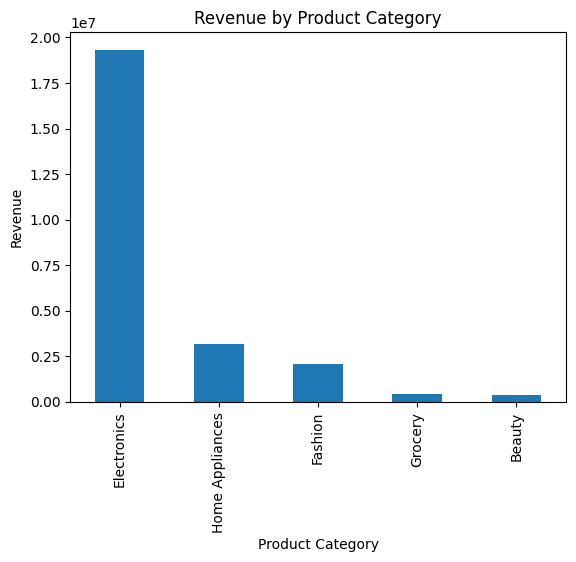

In [3]:
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

## Analysis 2: Monthly Revenue Trend

### Business Question

How does Lulu Mall's revenue change throughout the year?

### Objective

To identify monthly sales trends and periods of high or low revenue.

### Approach

The transaction dates are converted into months, and total revenue is aggregated for each month.

### Expected Business Use

Monthly trend analysis can help management identify seasonal fluctuations and plan marketing campaigns, inventory, and promotional activities around high-demand periods.

In [6]:
# Monthly Revenue Analysis

monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .sort_index()
)

print(monthly_revenue)

Month
1     1797626
2     1780460
3     2665114
4     2912064
5     2141683
6     2408436
7     1852181
8     2465375
9     2034330
10    1427469
11    1720173
12    2211311
Name: Revenue, dtype: int64


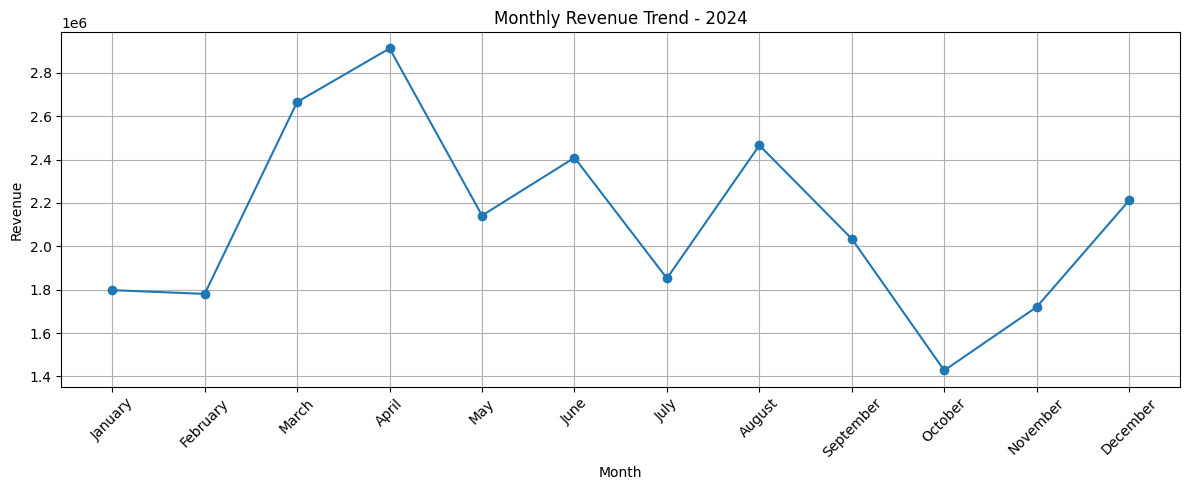

In [5]:
monthly_revenue = (
    df.groupby("Month_Name")["Revenue"]
      .sum()
      .reindex([
          "January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"
      ])
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend - 2024")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

## Analysis 3: Revenue by State

### Business Question

Which states contribute the most revenue to Lulu Mall?

### Objective

To compare sales performance across different states and identify high-performing markets.

### Approach

Revenue is grouped by `State` and sorted in descending order.

### Expected Business Use

State-level analysis helps management understand geographic performance and identify locations with strong revenue contribution.

In [7]:
# Revenue by State

state_revenue = (
    df.groupby("State")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(state_revenue)

State
Tamil Nadu       5166966
Karnataka        4333457
Telangana        3783603
Maharashtra      3608419
Delhi            3471007
Kerala           2680969
Uttar Pradesh    2371801
Name: Revenue, dtype: int64


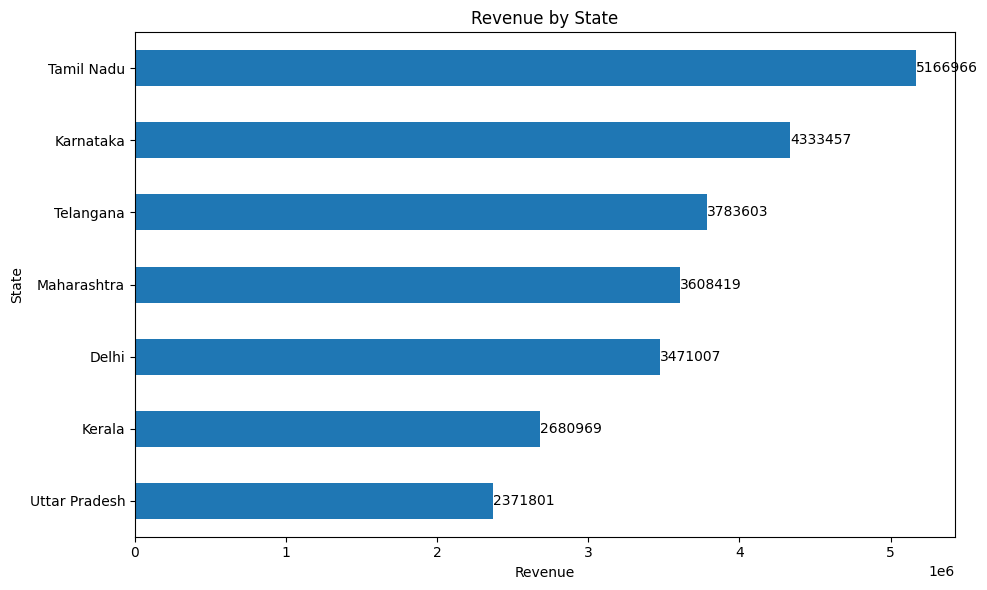

In [10]:
plt.figure(figsize=(10, 6))

ax = state_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Revenue by State")
plt.xlabel("Revenue")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Analysis 4: Store Performance Analysis

### Business Question

Which Lulu Mall stores generate the highest revenue?

### Objective

To compare revenue performance across individual Lulu Mall stores.

### Approach

The dataset is grouped by `Store_Name` and total revenue is calculated for each store.

### Expected Business Use

Store-level analysis can help management identify high-performing locations and compare performance across different mall branches.

In [11]:
# Revenue by Store

store_revenue = (
    df.groupby("Store_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(store_revenue)

Store_Name
Lulu Mall Bangalore     4333457
Lulu Mall Chennai       3920110
Lulu Mall Hyderabad     3783603
Lulu Mall Mumbai        3608419
Lulu Mall Delhi         3471007
Lulu Mall Kochi         2680969
Lulu Mall Lucknow       2371801
Lulu Mall Coimbatore    1246856
Name: Revenue, dtype: int64


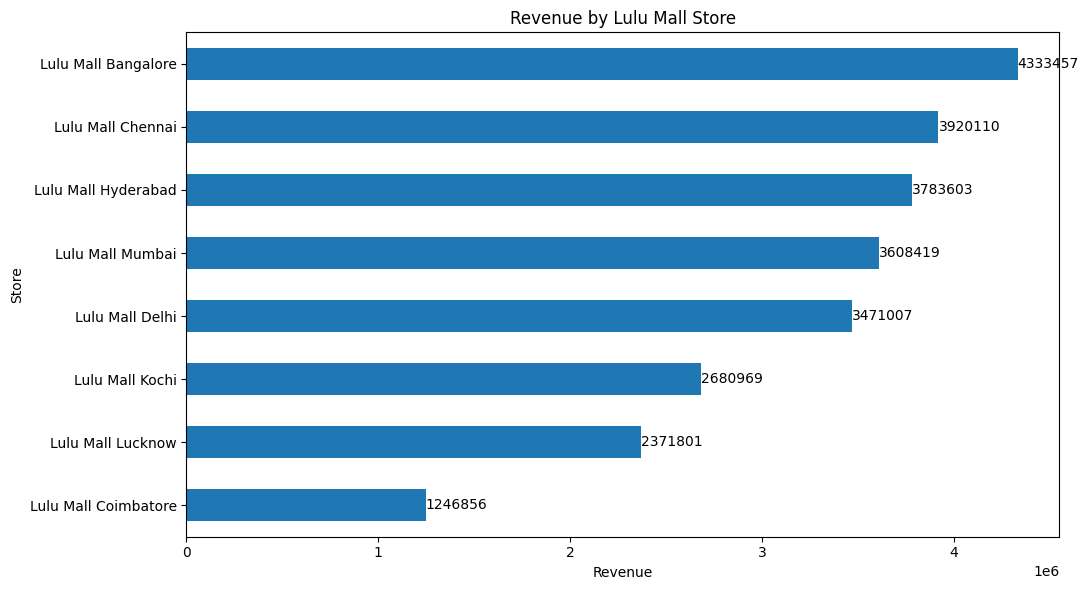

In [13]:
plt.figure(figsize=(11, 6))

ax = store_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Lulu Mall Store")
plt.xlabel("Revenue")
plt.ylabel("Store")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Analysis 5: Revenue by Payment Mode

### Business Question

Which payment methods contribute the most revenue?

### Objective

To understand customer payment preferences across different transaction methods.

### Approach

Revenue is grouped by `Payment_Mode` and aggregated to compare the contribution of each payment method.

### Expected Business Use

Payment-mode analysis can help management understand transaction preferences and optimize digital payment options and checkout operations.

In [14]:
# Revenue by Payment Mode

payment_revenue = (
    df.groupby("Payment_Mode")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(payment_revenue)

Payment_Mode
Cash           4835877
UPI            4605354
Credit Card    4384915
Net Banking    4089914
Debit Card     4079407
EMI            3420755
Name: Revenue, dtype: int64


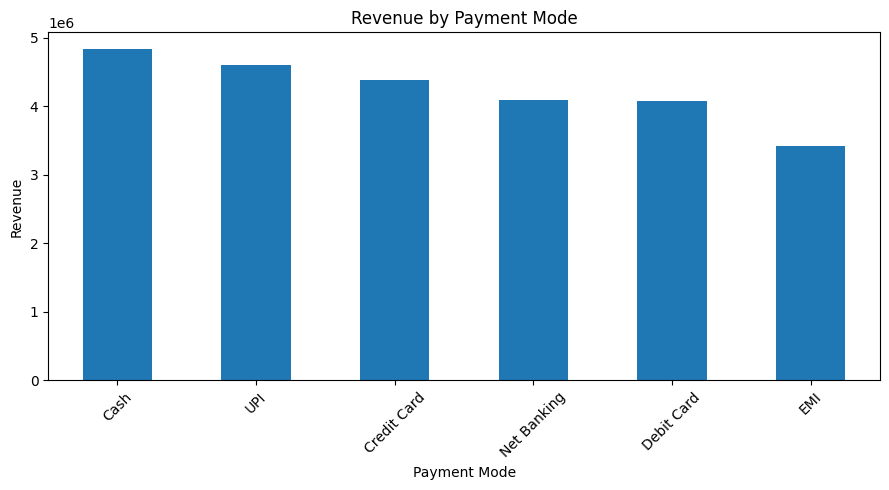

In [15]:
plt.figure(figsize=(9, 5))

payment_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analysis 6: Revenue by Customer Gender

### Business Question

How is revenue distributed across customer genders?

### Objective

To compare purchasing contribution between male and female customers.

### Approach

Revenue is grouped by `Customer_Gender` and aggregated to determine the contribution of each gender.

### Expected Business Use

This analysis can help management understand customer composition and support targeted marketing and product strategies.

In [16]:
# Revenue by Customer Gender

gender_revenue = (
    df.groupby("Customer_Gender")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(gender_revenue)

Customer_Gender
Male      14792492
Female    10623730
Name: Revenue, dtype: int64


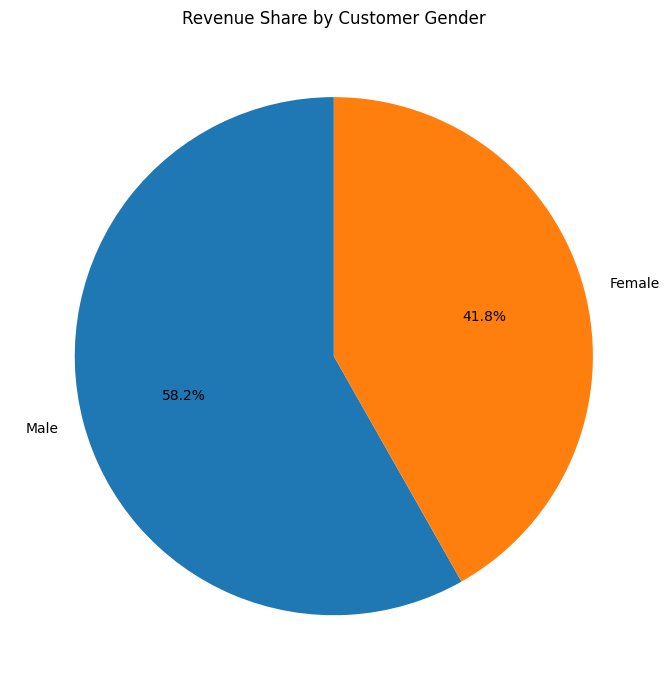

In [17]:
plt.figure(figsize=(7, 7))

gender_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Customer Gender")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Analysis 7: Revenue by Region

### Business Question

Which region contributes the most revenue to Lulu Mall?

### Objective

To compare revenue performance across different regions and identify the strongest-performing geographic market.

### Approach

The sales data is grouped by `Region`, and total revenue is calculated for each region. The results are then sorted to compare regional performance.

### Expected Business Use

Regional revenue analysis can help management evaluate geographic performance, identify strong and weak markets, and support regional sales and marketing strategies.

In [18]:
category_analysis = (
    df.groupby("Product_Category")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

print(category_analysis)

                  Total_Revenue  Total_Quantity  Total_Orders
Product_Category                                             
Electronics            19322167             529           249
Home Appliances         3178607             386           193
Fashion                 2102009             587           278
Grocery                  410889             636           313
Beauty                   402550             350           167


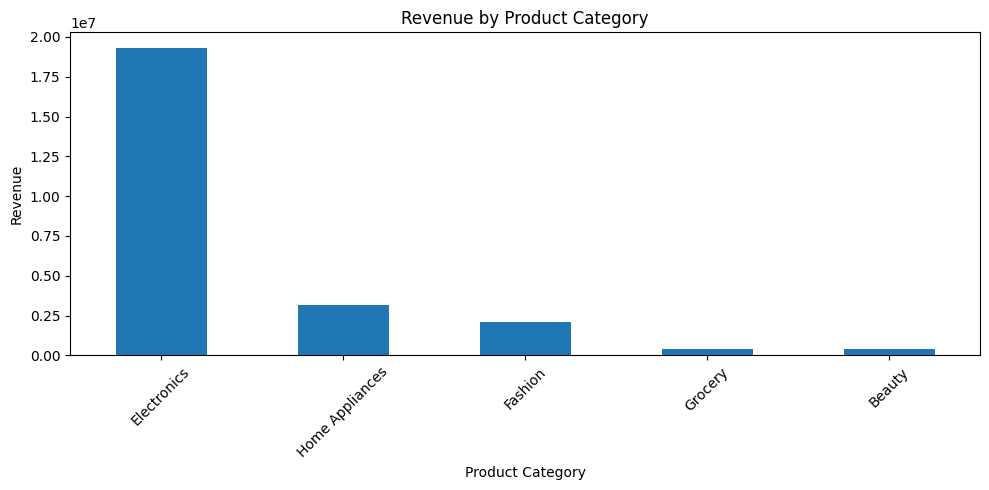

In [19]:
plt.figure(figsize=(10, 5))

category_analysis["Total_Revenue"].plot(
    kind="bar"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

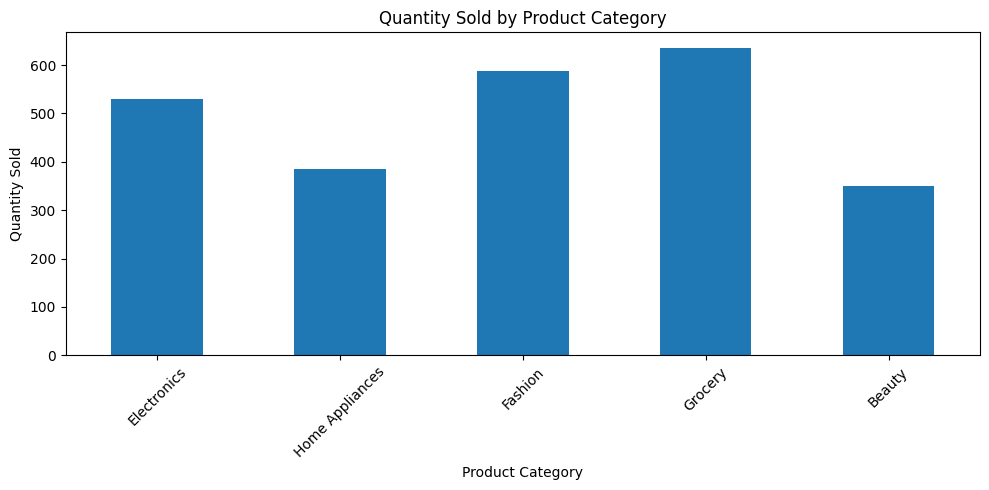

In [20]:
plt.figure(figsize=(10, 5))

category_analysis["Total_Quantity"].plot(
    kind="bar"
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analysis 8: Customer Revenue Analysis

### Business Question

Which customers contribute the most revenue to Lulu Mall?

### Objective

To identify high-value customers based on their total spending.

### Approach

Customer transactions are grouped by `Customer_ID`, and total revenue is calculated for each customer. The customers are then ranked based on their total revenue contribution.

### Key Metrics

- Customer ID
- Total Revenue
- Number of Orders
- Total Quantity Purchased
- Average Order Value

### Expected Business Use

Identifying high-value customers can help management develop customer retention strategies, personalized promotions, and loyalty programs.

In [21]:
customer_analysis = (
    df.groupby("Customer_ID")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
      .reset_index()
)

customer_analysis["Average_Order_Value"] = (
    customer_analysis["Total_Revenue"] /
    customer_analysis["Total_Orders"]
)

customer_analysis.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
0,CUST0001,177,1,1,177.0
1,CUST0002,3766,1,2,3766.0
2,CUST0003,866,1,2,866.0
3,CUST0005,2439,1,1,2439.0
4,CUST0006,12578,4,7,3144.5


In [22]:
top_customers = (
    customer_analysis
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
212,CUST0284,494301,5,12,98860.200000
458,CUST0605,411035,3,9,137011.666667
570,CUST0739,402371,3,10,134123.666667
213,CUST0285,401573,4,10,100393.250000
357,CUST0469,387225,4,9,96806.250000
78,CUST0111,340118,4,8,85029.500000
319,CUST0422,321907,2,9,160953.500000
542,CUST0708,305429,4,9,76357.250000
455,CUST0602,303700,2,10,151850.000000
305,CUST0403,298582,2,7,149291.000000


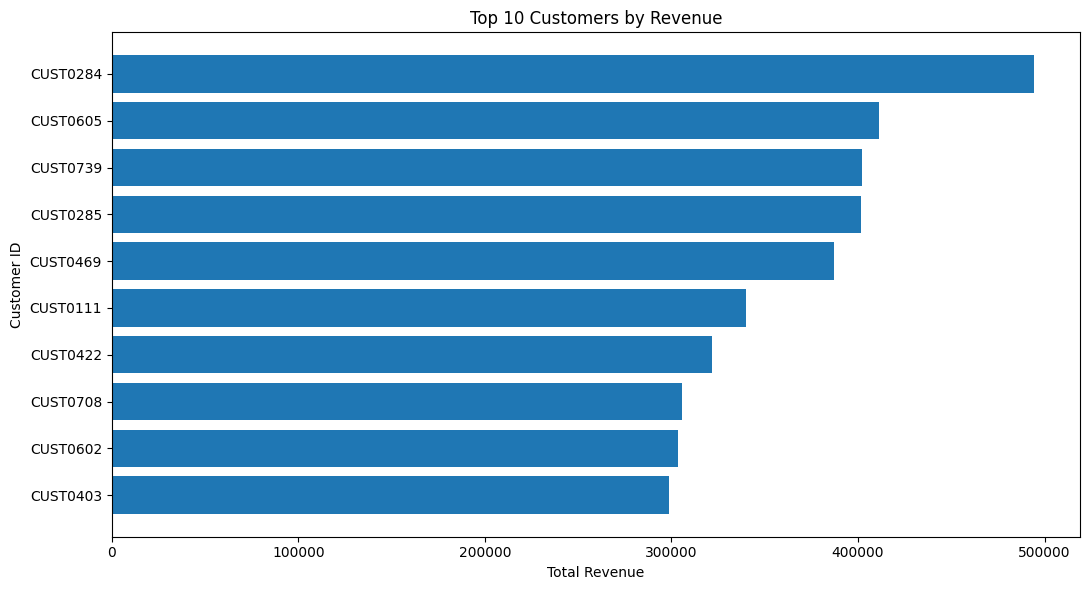

In [23]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_customers["Customer_ID"],
    top_customers["Total_Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()